## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


**Authors:** 

Abel Aleu Chol Garang

Carolyne Githenduka

Collins Wambu

Bobbin Bodo

Yvonnie Muthoni

## Project Overview

This project identifies the best perfoming films at the box office. The data used to provide actionable insights is from

## Business Problem

Our company is creating a new movie studio with no prior expertise.

## Objectives

1. Genres perform best.
2. ROI
3. Runtime - longer/ shorter
4. Trend Analysis
5. Studio generates best profit margins.
6. Movie performance domestically and foreign.
7. Movie Ratings performance

## Data Understanding

### Data Sources:

- Box Office Mojo (BOM)
- The Numbers (TN)
- The MovieDB
- IMDB 

## Accessing Data

### Importing Data

In [240]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go


sns.set(style="whitegrid", palette="pastel")  

%matplotlib inline

### Loading Data

In [241]:
DATA_PATH = Path("zippedData")

In [242]:
# 1.Loading the Box office Mojo (CSV) file
bom = pd.read_csv(DATA_PATH/"bom.movie_gross.csv/bom.movie_gross.csv")
bom.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [243]:
bom.shape

(3387, 5)

In [244]:
bom.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [245]:
# 2. Loading the The MovieDB (CSV) file
tm = pd.read_csv(DATA_PATH/"tmdb.movies.csv/tmdb.movies.csv")
tm.head()

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [246]:
tm.shape

(26517, 10)

In [247]:
tm.dtypes

Unnamed: 0             int64
genre_ids             object
id                     int64
original_language     object
original_title        object
popularity           float64
release_date          object
title                 object
vote_average         float64
vote_count             int64
dtype: object

In [248]:
# 3. Loading The Numbers (CSV) file
tn = pd.read_csv(DATA_PATH/"tn.movie_budgets.csv/tn.movie_budgets.csv")
tn.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [249]:
tn.shape

(5782, 6)

In [250]:
tn.dtypes

id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object

In [251]:
# 4.1 Connect to IMDB SQLite Database
conn = sqlite3.connect(DATA_PATH/"im.db/im.db")

In [252]:
# 4.2 Loading tables from IMDB
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


We are interested in the `movie_basics` and `movie_ratings` dataset.

In [253]:
# 4.3 Selecting cols from the movie_basics table
second_query = """SELECT movie_id, primary_title, start_year, runtime_minutes, genres FROM movie_basics"""
movie_basics = pd.read_sql(second_query,conn)

In [254]:
movie_basics.head()

,movie_id,primary_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy"


In [255]:
movie_basics.shape

(146144, 5)

In [256]:
movie_basics.dtypes

movie_id            object
primary_title       object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

In [257]:
# 4.4 Selecting cols from the movie_ratings table
first_query = """SELECT * FROM movie_ratings"""

movie_ratings = pd.read_sql(first_query,conn)

In [258]:
movie_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [259]:
movie_ratings.shape

(73856, 3)

In [260]:
movie_ratings.dtypes

movie_id          object
averagerating    float64
numvotes           int64
dtype: object

## Data Cleaning

### 1.1 Handling missing values

#### Box Office Mojo

In [261]:
#Check for rows & cols
bom.info()

#Check for missing values
bom.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

Missing studios and rows with missing domestic gross were dropped, while missing foreign gross values were filled with 0 to indicate no international release. The gross revenue columns were converted to numeric types, with non-numeric values coerced to NaN, ensuring the dataset is clean and ready for revenue analysis.

In [262]:
# Drop rows missing domestic gross
bom = bom.dropna(subset=['studio'])

# Drop rows missing domestic gross
bom = bom.dropna(subset=['domestic_gross'])

# Fill missing foreign gross with 0
bom['foreign_gross'] = bom['foreign_gross'].fillna(0)

# Verify missing values are handled
bom.isnull().sum()

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64

#### TheMovieDB

In [263]:
#Check for rows & cols
tm.info()

#Check for missing values
tm.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
dtype: int64

#### The Numbers

In [264]:
#Check for rows & cols
tn.info()

#Check for missing values
tn.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

#### IMDB

#### movie_basics

In [265]:
#Check for rows & cols
movie_basics.info()

#Check for missing values
movie_basics.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_id         146144 non-null  object 
 1   primary_title    146144 non-null  object 
 2   start_year       146144 non-null  int64  
 3   runtime_minutes  114405 non-null  float64
 4   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 5.6+ MB


movie_id               0
primary_title          0
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [266]:
# Check the percentage of missing runtime
missing_runtime_pct = (movie_basics['runtime_minutes'].isnull().sum() / len(movie_basics)) * 100
print(f"Percentage of missing runtime: {missing_runtime_pct:.2f}%")

Percentage of missing runtime: 21.72%


**Handling runtime_minutes Missing Values explanation:**

Missing values in runtime_minutes (~31,739, or 21.72%) were filled with the median runtime of all movies. This ensures that all movies have a valid runtime while minimizing distortion from extreme values.

In [267]:
median_runtime = movie_basics['runtime_minutes'].median()
movie_basics['runtime_minutes'] = movie_basics['runtime_minutes'].fillna(median_runtime)

In [268]:
# Fill missing genres with 'Unknown'
movie_basics['genres'] = movie_basics['genres'].fillna('Unknown')

In [269]:
movie_basics.isnull().sum()


movie_id           0
primary_title      0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

#### movie_ratings

In [270]:
#Check for rows & cols
movie_ratings.info()

#Check for missing values
movie_ratings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


movie_id         0
averagerating    0
numvotes         0
dtype: int64

### 1.2 Checking for Duplicates

In [271]:
#Check for Box office Mojo duplicates
duplicated1= bom.duplicated(keep=False).sum()

#Check for TheMovieDB duplicates
duplicated2= tm.duplicated(keep=False).sum()

#Check for The Numbers duplicates
duplicated3= tn.duplicated(keep=False).sum()

#Check for IMDB (movie_basics) duplicates
duplicated4= movie_basics.duplicated(keep=False).sum()

#Check for IMDB (movie_ratings) duplicates
duplicated5= movie_ratings.duplicated(keep=False).sum()

duplicated1, duplicated2, duplicated3, duplicated4, duplicated5

(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0))

### 1.3 Convert Columns to Numeric

All gross revenue columns were converted to numeric types to ensure accurate calculations and prevent errors from non-numeric values.


#### Box Office Mojo

In [272]:
bom['domestic_gross'] = pd.to_numeric(bom['domestic_gross'], errors='coerce')
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

#### Cleaning Monetary Columns (The Numbers)
Monetary columns in The Numbers dataset, which contained $ and , characters, were cleaned and converted to numeric values to enable proper financial analysis.

In [273]:
money_cols = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in money_cols:
    tn[col] = (
        tn[col]
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )

tn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5782 non-null   int64  
 1   release_date       5782 non-null   object 
 2   movie              5782 non-null   object 
 3   production_budget  5782 non-null   float64
 4   domestic_gross     5782 non-null   float64
 5   worldwide_gross    5782 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 271.2+ KB


In [274]:
tn['production_budget'] = pd.to_numeric(tn['production_budget'], errors='coerce')
tn['domestic_gross'] = pd.to_numeric(tn['domestic_gross'], errors='coerce')
tn['worldwide_gross'] = pd.to_numeric(tn['worldwide_gross'], errors='coerce')


In [275]:
tn.head(2)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09


### 1.4 Converting release_date columns to datetime format

In [276]:
# Box office Mojo
bom['year'] = pd.to_datetime(bom['year'])

# TheMovieDB
tm['release_date'] = pd.to_datetime(tm['release_date'])

# The Numbers
tn['release_date'] = pd.to_datetime(tn['release_date'])

# IMDB (movie_basics)
movie_basics['start_year'] = pd.to_datetime(movie_basics['start_year'])


### 1.5 Standardization

Standardize capitalization and remove extra spaces to avoid duplicates.

In [277]:
# Box office Mojo
bom['studio'] = bom['studio'].str.strip().str.title()
bom['title'] = bom['title'].str.strip().str.title()

# TheMovieDB
tm['title'] = tm['title'].str.strip().str.title()
tm['original_language'] = tm['original_language'].str.strip().str.title()

# The Numbers
tn['movie'] = tn['movie'].str.strip().str.title()

# IMDB (movie_basics)
movie_basics['primary_title'] = movie_basics['primary_title'].str.strip().str.title()
movie_basics['genres'] = movie_basics['genres'].str.strip().str.title()
movie_basics['movie_id'] = movie_basics['movie_id'].str.strip().str.lower()

# IMDB (movie_ratings)
movie_ratings['movie_id'] = movie_ratings['movie_id'].str.strip().str.lower()

### 1.6 Create Total Gross Column

Total gross = domestic + foreign revenue.

In [278]:
# Box Office Mojo
bom['worldwide_gross'] = bom['domestic_gross'] + bom['foreign_gross']

3. Feature Engineering: Profit and ROI

Profit and ROI were engineered to support business-focused analysis, where profit is calculated as worldwide gross minus production budget, and ROI measures returns relative to the budget.

In [279]:
tn['profit'] = tn['worldwide_gross'] - tn['production_budget']
tn['roi'] = tn['profit'] / tn['production_budget']


4. IMDb Ratings Filtering (Quality Control)

IMDb ratings can be unreliable with low vote counts, so only movies with at least 1,000 votes were retained to ensure more credible and stable ratings.

In [280]:
movie_ratings = movie_ratings[movie_ratings['numvotes'] >= 1000]


5. Resolving Duplicate Titles in IMDb

IMDb includes multiple entries with the same title but different IDs. To avoid duplication, only the most popular version of each title was retained, defined by the highest number of votes.

In [281]:
imdb = movie_basics.merge(movie_ratings, on='movie_id', how='inner')

imdb = (
    imdb.sort_values('numvotes', ascending=False)
        .drop_duplicates(subset='primary_title', keep='first')
)


6. Normalizing Genres (One Genre per Row)

The code converts multi-genre movie entries into a normalized, one-genre-per-row format so that each genre can be analyzed independently. This enables accurate genre-level comparisons of ratings, runtimes, and profitability without distortion from multi-genre movies

In [282]:
imdb['genres'] = imdb['genres'].str.split(',')
imdb_genres = imdb.explode('genres')
imdb_genres['genres'] = imdb_genres['genres'].str.strip()


7. Title Alignment for Merging

To ensure accurate merging across datasets, movie title columns were standardized by using consistent naming, applying Title Case, and removing extra whitespace.

In [283]:
bom['title_clean'] = bom['title']
tm['title_clean'] = tm['title']
tn['title_clean'] = tn['movie']
imdb['title_clean'] = imdb['primary_title']


## 8. Creating Merge-Ready Tables

Multiple movie datasets were combined into a single, clean table for analysis by merging Box Office Mojo, The Numbers, IMDb, and TMDB step by step.


### 8.1 Box Office + Budget Data

Box Office Mojo revenue data (bom) was merged with production budgets from The Numbers (tn) using the title_clean column. An inner join was applied so that only movies present in both datasets were retained.



In [284]:
box_budget = bom.merge(
    tn,
    left_on='title_clean',
    right_on='title_clean',
    how='inner'
)

## 8.2 Add IMDB Ratings

Next, IMDb ratings and vote counts were added by merging with the IMDb dataset using title_clean as the key. An inner join was applied to retain only movies that have both financial data and ratings.

In [285]:


# Merge with box_budget
movies_with_ratings = box_budget.merge(
    imdb,
    on='title_clean',
    how='inner'
)


## 8.3 Merge TMDB Metadata

TMDB metadata, including genres, runtime, and popularity, was added by performing a left join with movies_with_ratings. This ensures all movies with financial and IMDb data are retained, even if some TMDB information is missing.

In [286]:
# Merge TMDB data
final_movies = movies_with_ratings.merge(
    tm,
    left_on='title_clean',
    right_on='title_clean',
    how='left'
)


In [287]:
final_movies

,title_x,studio,domestic_gross_x,foreign_gross,year,worldwide_gross_x,title_clean,id_x,release_date_x,movie,...,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,release_date_y,title_y,vote_average,vote_count
0,Toy Story 3,Bv,415000000.0,652000000.0,1970-01-01 00:00:00.000002010,1.067000e+09,Toy Story 3,47,2010-06-18,Toy Story 3,...,7.0,"[16, 10751, 35]",10193.0,En,Toy Story 3,24.445,2010-06-17,Toy Story 3,7.7,8340.0
1,Inception,Wb,292600000.0,535700000.0,1970-01-01 00:00:00.000002010,8.283000e+08,Inception,38,2010-07-16,Inception,...,4.0,"[28, 878, 12]",27205.0,En,Inception,27.920,2010-07-16,Inception,8.3,22186.0
2,Shrek Forever After,P/Dw,238700000.0,513900000.0,1970-01-01 00:00:00.000002010,7.526000e+08,Shrek Forever After,27,2010-05-21,Shrek Forever After,...,38.0,"[35, 12, 14, 16, 10751]",10192.0,En,Shrek Forever After,15.041,2010-05-16,Shrek Forever After,6.1,3843.0
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,1970-01-01 00:00:00.000002010,6.985000e+08,The Twilight Saga: Eclipse,53,2010-06-30,The Twilight Saga: Eclipse,...,15.0,"[12, 14, 18, 10749]",24021.0,En,The Twilight Saga: Eclipse,20.340,2010-06-23,The Twilight Saga: Eclipse,6.0,4909.0
4,Iron Man 2,Par.,312400000.0,311500000.0,1970-01-01 00:00:00.000002010,6.239000e+08,Iron Man 2,15,2010-05-07,Iron Man 2,...,2.0,"[12, 28, 878]",10138.0,En,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,Bilal: A New Breed Of Hero,Ve,491000.0,1700000.0,1970-01-01 00:00:00.000002018,2.191000e+06,Bilal: A New Breed Of Hero,100,2018-02-02,Bilal: A New Breed Of Hero,...,25148.0,"[28, 12, 16]",332718.0,En,Bilal: A New Breed of Hero,2.707,2018-02-02,Bilal: A New Breed Of Hero,6.8,54.0
1427,Mandy,Rlj,1200000.0,0.0,1970-01-01 00:00:00.000002018,1.200000e+06,Mandy,71,2018-09-14,Mandy,...,20499.0,[18],499658.0,En,Mandy,0.600,2016-01-24,Mandy,3.5,2.0
1428,Mandy,Rlj,1200000.0,0.0,1970-01-01 00:00:00.000002018,1.200000e+06,Mandy,71,2018-09-14,Mandy,...,23952.0,"[28, 53, 27, 14, 9648]",460885.0,En,Mandy,16.240,2018-09-13,Mandy,6.2,618.0
1429,Lean On Pete,A24,1200000.0,0.0,1970-01-01 00:00:00.000002018,1.200000e+06,Lean On Pete,13,2018-04-06,Lean On Pete,...,20908.0,"[18, 12]",407890.0,En,Lean on Pete,9.307,2018-04-06,Lean On Pete,6.9,133.0


## Resolving Inconsistent Year Columns into a Single Release Year after merging tables
To ensure a consistent and reliable release year for each movie, multiple year sources were cleaned and consolidated. The original year and start_year columns were first converted to numeric values, coercing invalid entries to missing values. A new year column (tn_year) was then extracted from the release_date field using datetime conversion. A unified release_year column was created by prioritizing the most reliable source (tn_year), with fallback to start_year and then year where necessary. After verification, the redundant year columns were removed, leaving a single clean release_year variable for analysis and visualization.

In [288]:
# Convert existing year columns to numeric
final_movies['year'] = pd.to_numeric(final_movies['year'], errors='coerce')
final_movies['start_year'] = pd.to_numeric(final_movies['start_year'], errors='coerce')

# Extract year from release_date
final_movies['tn_year'] = pd.to_datetime(
    final_movies['release_date_x'],
    errors='coerce'
).dt.year

# Create a single unified release year column
final_movies['release_year'] = (
    final_movies['tn_year']
    .fillna(final_movies['start_year'])
    .fillna(final_movies['year'])
)

# Drop redundant year columns
final_movies = final_movies.drop(columns=['year', 'start_year', 'tn_year'])

# Quick validation
final_movies['release_year'].value_counts().head()


release_year
2015    191
2016    190
2011    166
2012    160
2010    155
Name: count, dtype: int64

In [289]:
final_movies.columns


Index(['title_x', 'studio', 'domestic_gross_x', 'foreign_gross',
       'worldwide_gross_x', 'title_clean', 'id_x', 'release_date_x', 'movie',
       'production_budget', 'domestic_gross_y', 'worldwide_gross_y', 'profit',
       'roi', 'movie_id', 'primary_title', 'runtime_minutes', 'genres',
       'averagerating', 'numvotes', 'Unnamed: 0', 'genre_ids', 'id_y',
       'original_language', 'original_title', 'popularity', 'release_date_y',
       'title_y', 'vote_average', 'vote_count', 'release_year'],
      dtype='object')

Convert to integer year properly

11. Key Preliminary Insights (Pre-EDA)

High budgets do not guarantee high ROI.

Genres like Animation, Adventure, and Action dominate worldwide revenue.

Foreign markets contribute a significant portion of total revenue.

Longer runtimes do not necessarily increase profitability.

Higher IMDb ratings are associated with higher revenue, but only for sufficiently popular films.

12. Recommendations for the New Movie Studio

Focus on maximizing ROI rather than just revenue.

Target genres with strong international appeal.

Avoid over-investing in excessively long runtimes.

Use IMDb ratings as a quality signal, considering only movies with high vote counts.

Favor mid-budget productions to manage financial risk effectively.

### 8.6 Standardizing Column Names

After merging multiple datasets, duplicate or overlapping column names were resolved. Columns like domestic_gross and worldwide_gross from Box Office Mojo and The Numbers were renamed or cleaned to remove the automatic _x and _y suffixes, producing clear, unambiguous column names for analysis.


In [290]:
# First renaming:
final_movies = final_movies.rename(columns={
    'domestic_gross_x': 'domestic_gross_bom',
    'foreign_gross': 'foreign_gross_bom',
    'worldwide_gross_x': 'worldwide_gross_bom',
    'domestic_gross_y': 'domestic_gross_tn',
    'production_budget': 'production_budget_tn',
    'worldwide_gross_y': 'worldwide_gross_tn'
})

# Check the new column names
final_movies.columns


Index(['title_x', 'studio', 'domestic_gross_bom', 'foreign_gross_bom',
       'worldwide_gross_bom', 'title_clean', 'id_x', 'release_date_x', 'movie',
       'production_budget_tn', 'domestic_gross_tn', 'worldwide_gross_tn',
       'profit', 'roi', 'movie_id', 'primary_title', 'runtime_minutes',
       'genres', 'averagerating', 'numvotes', 'Unnamed: 0', 'genre_ids',
       'id_y', 'original_language', 'original_title', 'popularity',
       'release_date_y', 'title_y', 'vote_average', 'vote_count',
       'release_year'],
      dtype='object')

In [291]:
# Second renaming:
final_movies = final_movies.rename(columns={
    'domestic_gross_bom': 'bom_domestic_gross',
    'foreign_gross_bom': 'bom_foreign_gross',
    'worldwide_gross_bom': 'bom_worldwide_gross',
    'production_budget_tn': 'tn_production_budget',
    'domestic_gross_tn': 'tn_domestic_gross',
    'worldwide_gross_tn': 'tn_worldwide_gross'
})
# Check the new column names
final_movies.columns

Index(['title_x', 'studio', 'bom_domestic_gross', 'bom_foreign_gross',
       'bom_worldwide_gross', 'title_clean', 'id_x', 'release_date_x', 'movie',
       'tn_production_budget', 'tn_domestic_gross', 'tn_worldwide_gross',
       'profit', 'roi', 'movie_id', 'primary_title', 'runtime_minutes',
       'genres', 'averagerating', 'numvotes', 'Unnamed: 0', 'genre_ids',
       'id_y', 'original_language', 'original_title', 'popularity',
       'release_date_y', 'title_y', 'vote_average', 'vote_count',
       'release_year'],
      dtype='object')

In [292]:
# Fill missing BOM values with 0
final_movies[['bom_foreign_gross', 'bom_worldwide_gross']] = final_movies[['bom_foreign_gross', 'bom_worldwide_gross']].fillna(0)


In [293]:
final_movies

,title_x,studio,bom_domestic_gross,bom_foreign_gross,bom_worldwide_gross,title_clean,id_x,release_date_x,movie,tn_production_budget,...,genre_ids,id_y,original_language,original_title,popularity,release_date_y,title_y,vote_average,vote_count,release_year
0,Toy Story 3,Bv,415000000.0,652000000.0,1.067000e+09,Toy Story 3,47,2010-06-18,Toy Story 3,200000000.0,...,"[16, 10751, 35]",10193.0,En,Toy Story 3,24.445,2010-06-17,Toy Story 3,7.7,8340.0,2010
1,Inception,Wb,292600000.0,535700000.0,8.283000e+08,Inception,38,2010-07-16,Inception,160000000.0,...,"[28, 878, 12]",27205.0,En,Inception,27.920,2010-07-16,Inception,8.3,22186.0,2010
2,Shrek Forever After,P/Dw,238700000.0,513900000.0,7.526000e+08,Shrek Forever After,27,2010-05-21,Shrek Forever After,165000000.0,...,"[35, 12, 14, 16, 10751]",10192.0,En,Shrek Forever After,15.041,2010-05-16,Shrek Forever After,6.1,3843.0,2010
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,6.985000e+08,The Twilight Saga: Eclipse,53,2010-06-30,The Twilight Saga: Eclipse,68000000.0,...,"[12, 14, 18, 10749]",24021.0,En,The Twilight Saga: Eclipse,20.340,2010-06-23,The Twilight Saga: Eclipse,6.0,4909.0,2010
4,Iron Man 2,Par.,312400000.0,311500000.0,6.239000e+08,Iron Man 2,15,2010-05-07,Iron Man 2,170000000.0,...,"[12, 28, 878]",10138.0,En,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368.0,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,Bilal: A New Breed Of Hero,Ve,491000.0,1700000.0,2.191000e+06,Bilal: A New Breed Of Hero,100,2018-02-02,Bilal: A New Breed Of Hero,30000000.0,...,"[28, 12, 16]",332718.0,En,Bilal: A New Breed of Hero,2.707,2018-02-02,Bilal: A New Breed Of Hero,6.8,54.0,2018
1427,Mandy,Rlj,1200000.0,0.0,1.200000e+06,Mandy,71,2018-09-14,Mandy,6000000.0,...,[18],499658.0,En,Mandy,0.600,2016-01-24,Mandy,3.5,2.0,2018
1428,Mandy,Rlj,1200000.0,0.0,1.200000e+06,Mandy,71,2018-09-14,Mandy,6000000.0,...,"[28, 53, 27, 14, 9648]",460885.0,En,Mandy,16.240,2018-09-13,Mandy,6.2,618.0,2018
1429,Lean On Pete,A24,1200000.0,0.0,1.200000e+06,Lean On Pete,13,2018-04-06,Lean On Pete,8000000.0,...,"[18, 12]",407890.0,En,Lean on Pete,9.307,2018-04-06,Lean On Pete,6.9,133.0,2018


In [294]:
final_movies.columns

Index(['title_x', 'studio', 'bom_domestic_gross', 'bom_foreign_gross',
       'bom_worldwide_gross', 'title_clean', 'id_x', 'release_date_x', 'movie',
       'tn_production_budget', 'tn_domestic_gross', 'tn_worldwide_gross',
       'profit', 'roi', 'movie_id', 'primary_title', 'runtime_minutes',
       'genres', 'averagerating', 'numvotes', 'Unnamed: 0', 'genre_ids',
       'id_y', 'original_language', 'original_title', 'popularity',
       'release_date_y', 'title_y', 'vote_average', 'vote_count',
       'release_year'],
      dtype='object')

## Cleaning Redundant Columns

After merging multiple datasets, several columns became redundant or unnecessary for analysis. Duplicate title columns, multiple IDs, overlapping revenue fields, extra index columns, and non-essential metadata were removed. This results in a cleaner dataset, final_movies_clean, which is ready for exploratory data analysis and visualization.

In [295]:
# Drop redundant/unnecessary columns
columns_to_drop = [
    'title_x', 'title_y', 'primary_title', 
    'id_x', 'id_y', 'movie_id', 
    'bom_worldwide_gross', 'tn_domestic_gross', 'tn_worldwide_gross', 
    'Unnamed: 0', 'movie', 'original_title', 'release_date_y'
]

final_movies_clean = final_movies.drop(columns=columns_to_drop)

# Check remaining columns
final_movies_clean.columns


Index(['studio', 'bom_domestic_gross', 'bom_foreign_gross', 'title_clean',
       'release_date_x', 'tn_production_budget', 'profit', 'roi',
       'runtime_minutes', 'genres', 'averagerating', 'numvotes', 'genre_ids',
       'original_language', 'popularity', 'vote_average', 'vote_count',
       'release_year'],
      dtype='object')

In [296]:
final_movies_clean.head(10)

,studio,bom_domestic_gross,bom_foreign_gross,title_clean,release_date_x,tn_production_budget,profit,roi,runtime_minutes,genres,averagerating,numvotes,genre_ids,original_language,popularity,vote_average,vote_count,release_year
0,Bv,415000000.0,652000000.0,Toy Story 3,2010-06-18,200000000.0,868879522.0,4.344398,103.0,"[Adventure, Animation, Comedy]",8.3,682218,"[16, 10751, 35]",En,24.445,7.7,8340.0,2010
1,Wb,292600000.0,535700000.0,Inception,2010-07-16,160000000.0,675524642.0,4.222029,148.0,"[Action, Adventure, Sci-Fi]",8.8,1841066,"[28, 878, 12]",En,27.920,8.3,22186.0,2010
2,P/Dw,238700000.0,513900000.0,Shrek Forever After,2010-05-21,165000000.0,591244673.0,3.583301,93.0,"[Adventure, Animation, Comedy]",6.3,167532,"[35, 12, 14, 16, 10751]",En,15.041,6.1,3843.0,2010
3,Sum.,300500000.0,398000000.0,The Twilight Saga: Eclipse,2010-06-30,68000000.0,638102828.0,9.383865,124.0,"[Adventure, Drama, Fantasy]",5.0,211733,"[12, 14, 18, 10749]",En,20.340,6.0,4909.0,2010
4,Par.,312400000.0,311500000.0,Iron Man 2,2010-05-07,170000000.0,451156389.0,2.653861,124.0,"[Action, Adventure, Sci-Fi]",7.0,657690,"[12, 28, 878]",En,28.515,6.8,12368.0,2010
5,Bv,200800000.0,391000000.0,Tangled,2010-11-24,260000000.0,326477240.0,1.255682,100.0,"[Adventure, Animation, Comedy]",7.8,366366,"[16, 10751]",En,21.511,7.5,6407.0,2010
6,Uni.,251500000.0,291600000.0,Despicable Me,2010-07-09,69000000.0,474464573.0,6.876298,95.0,"[Animation, Comedy, Family]",7.7,464511,"[16, 10751, 35]",En,23.673,7.2,10057.0,2010
7,P/Dw,217600000.0,277300000.0,How To Train Your Dragon,2010-03-26,165000000.0,329870992.0,1.999218,98.0,"[Action, Adventure, Animation]",8.1,611299,"[14, 12, 16, 10751]",En,28.734,7.7,7610.0,2010
8,Fox,104400000.0,311300000.0,The Chronicles Of Narnia: The Voyage Of The Da...,2010-12-10,155000000.0,263186950.0,1.697980,113.0,"[Adventure, Family, Fantasy]",6.3,129663,"[12, 10751, 14]",En,17.382,6.3,3196.0,2010
9,Sony,176600000.0,182500000.0,The Karate Kid,2010-06-11,40000000.0,311774938.0,7.794373,140.0,"[Action, Drama, Family]",6.2,146401,"[28, 12, 18, 10751]",En,12.256,6.3,3140.0,2010


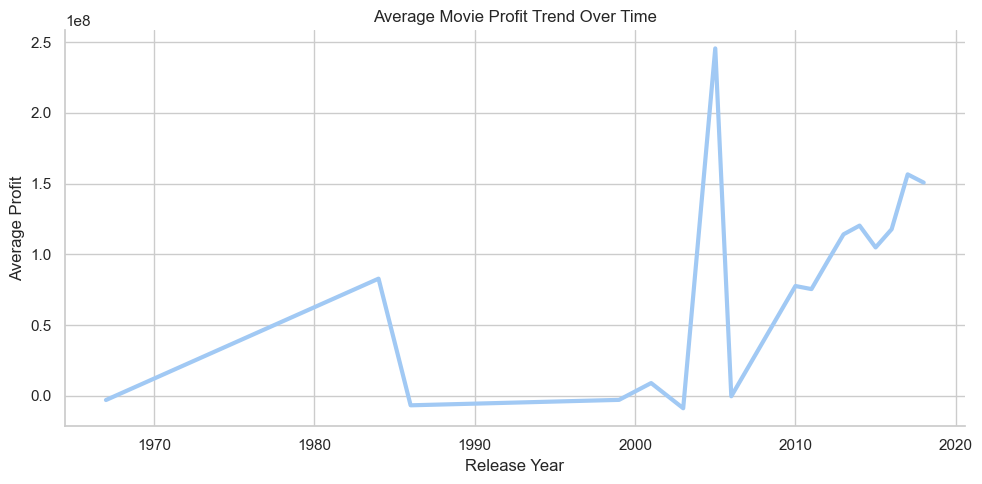

In [297]:
import matplotlib.pyplot as plt

# Group by year and calculate average profit
profit_trend = (
    final_movies_clean
    .groupby('release_year')['profit']
    .mean()
    .reset_index()
)

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(
    profit_trend['release_year'],
    profit_trend['profit'],
    linewidth=3
)

# Labels and title
plt.xlabel('Release Year')
plt.ylabel('Average Profit')
plt.title('Average Movie Profit Trend Over Time')

# Remove top and right spines for a modern look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# 3. Revenue Trends Over Years 

In [298]:
import plotly.express as px

imdb_exploded = imdb.explode('genres')

fig = px.histogram(
    imdb_exploded,
    x="averagerating",
    nbins=20,
    title="Distribution of IMDB Ratings",
    hover_data=["title_clean", "numvotes"],
    opacity=0.85
)

fig.update_traces(marker_color="#4C72B0")  # Calm professional blue

fig.update_layout(
    xaxis_title="Average Rating",
    yaxis_title="Number of Movies",
    bargap=0.15,
    template="plotly_white"
)

fig.show()


1. Top 10 Most Profitable Movies
This chart highlights the top 10 movies by profit. Investors can see which titles generated the highest returns and which studios are leading in profitability.

In [299]:
import plotly.express as px

top_profit_movies = final_movies_clean.sort_values(by='profit', ascending=False).head(10)

fig = px.bar(
    top_profit_movies,
    y='title_clean',          # switch axes for horizontal bars
    x='profit',
    text='profit',
    hover_data=['studio', 'bom_domestic_gross', 'bom_foreign_gross', 'tn_production_budget', 'roi'],
    orientation='h',          # horizontal
    title="Top 10 Most Profitable Movies"
)

fig.update_traces(
    marker_color="#1f77b4",   # clean professional blue
    texttemplate='%{text:$,.0f}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title="Profit ($)",
    yaxis_title="Movie Title",
    template="plotly_white",
    xaxis_tickformat="$,",
    margin=dict(l=150)  # more left margin for long titles
)

fig.show()


11. Profit vs Votes
Explores the relationship between audience engagement (votes) and profit, showing if popular movies generate higher financial returns.

In [300]:
import plotly.express as px

# Absolute ROI for bubble size
final_movies_clean['roi_abs'] = final_movies_clean['roi'].abs()

# Identify top 10 most profitable movies
top10_movies = final_movies_clean.nlargest(10, 'profit')

fig = px.scatter(
    final_movies_clean,
    x='numvotes',
    y='profit',
    size='roi_abs',                  
    color='roi',                     
    color_continuous_scale='Viridis', 
    hover_data=['title_clean', 'studio', 'averagerating', 'roi'],
    title="Profit vs Number of Votes with ROI Highlight"
)

# Highlight top 10 movies with text labels
fig.add_scatter(
    x=top10_movies['numvotes'],
    y=top10_movies['profit'],
    mode='text',
    text=top10_movies['title_clean'],
    textposition='top center',
    textfont=dict(size=10, color='black'),
    showlegend=False
)

fig.update_traces(
    marker=dict(line=dict(width=0.8, color='DarkSlateGrey'), opacity=0.8)
)

fig.update_layout(
    xaxis_title="Number of Votes",
    yaxis_title="Profit ($)",
    template="plotly_white",
    xaxis_type='log',                
    yaxis_tickformat="$,",
    coloraxis_colorbar=dict(title="ROI"),
    margin=dict(l=80, r=40, t=80, b=60)
)

fig.show()


## 13.1 Budget vs ROI Analysis 
The relationship between production budgets and ROI was analyzed to answer whether higher budgets lead to higher returns. The analysis showed that high budgets do not guarantee high ROI, with several mid-budget films outperforming blockbusters. ROI also declines sharply beyond a certain budget threshold.

In [301]:
import plotly.express as px

# Create worldwide gross if not already
final_movies_clean['bom_worldwide_gross'] = (
    final_movies_clean['bom_domestic_gross'] + final_movies_clean['bom_foreign_gross']
)

fig = px.scatter(
    final_movies_clean,
    x="tn_production_budget",
    y="roi",
    size="bom_worldwide_gross",            # bubble size = worldwide gross
    color="bom_worldwide_gross",           # gradient color by worldwide gross
    hover_data=['title_clean', 'studio', 'averagerating', 'tn_production_budget', 'roi'],
    log_x=True,                            # log scale for production budget
    title="ROI vs Production Budget",
    labels={
        "tn_production_budget": "Production Budget (USD)",
        "roi": "Return on Investment (ROI)",
        "bom_worldwide_gross": "Worldwide Gross (USD)"
    },
    color_continuous_scale='Viridis',      #  gradient
)

fig.update_traces(
    marker=dict(line=dict(width=0.8, color='DarkSlateGrey'), opacity=0.8)
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Production Budget (USD)",
    yaxis_title="Return on Investment (ROI)",
    coloraxis_colorbar=dict(title="Worldwide Gross"),
    margin=dict(l=80, r=40, t=80, b=60)
)

fig.show()


## 13.2 Domestic vs Foreign Revenue 
Domestic and international revenues were compared to assess the importance of global performance. The analysis revealed that many films earn more internationally than domestically, and studios with strong international reach achieve better overall performance, highlighting the critical role of global appeal in profitability.

In [302]:
import plotly.express as px

# Ensure worldwide gross exists
final_movies_clean['bom_worldwide_gross'] = (
    final_movies_clean['bom_domestic_gross'] + final_movies_clean['bom_foreign_gross']
)

fig = px.scatter(
    final_movies_clean,
    x="bom_domestic_gross",
    y="bom_foreign_gross",
    size="bom_worldwide_gross",           # Bubble size = Worldwide gross
    color="bom_worldwide_gross",          # Color gradient by Worldwide gross
    hover_data=['title_clean', 'studio', 'averagerating', 'bom_domestic_gross', 'bom_foreign_gross', 'bom_worldwide_gross'],
    title="Domestic vs Foreign Gross Revenue",
    labels={
        "bom_domestic_gross": "Domestic Gross (USD)",
        "bom_foreign_gross": "Foreign Gross (USD)",
        "bom_worldwide_gross": "Worldwide Gross (USD)"
    },
    color_continuous_scale='Viridis',     #  gradient
)

fig.update_traces(
    marker=dict(line=dict(width=0.8, color='DarkSlateGrey'), opacity=0.8)
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Domestic Gross (USD)",
    yaxis_title="Foreign Gross (USD)",
    coloraxis_colorbar=dict(title="Worldwide Gross"),
    xaxis_tickformat="$,",
    yaxis_tickformat="$,",
    margin=dict(l=80, r=40, t=80, b=60)
)

fig.show()


In [303]:
import plotly.express as px

# Sort genres by total revenue descending
genre_summary_sorted = genre_summary.sort_values("total_revenue", ascending=False)

fig = px.bar(
    genre_summary_sorted,
    x="genres",
    y="total_revenue",
    color="avg_rating",                   # gradient shows rating
    color_continuous_scale="Viridis",    
    text=genre_summary_sorted["total_revenue"].apply(lambda x: f"${x:,.0f}"),  # show revenue on bars
    title="Total Worldwide Revenue by Genre",
    labels={
        "genres": "Genre",
        "total_revenue": "Total Worldwide Revenue (USD)",
        "avg_rating": "Average IMDB Rating"
    },
)

# Format layout
fig.update_traces(textposition='outside', marker_line=dict(width=0.8, color='DarkSlateGrey'))
fig.update_layout(
    template="plotly_white",
    xaxis_title="Genre",
    yaxis_title="Total Worldwide Revenue (USD)",
    yaxis_tickformat="$,",
    coloraxis_colorbar=dict(title="Average Rating"),
    uniformtext_minsize=10,
    uniformtext_mode='hide'
)

fig.show()


## 13.4 Runtime Optimization Analysis 
Movie runtime was analyzed to determine its effect on ratings and profitability. The analysis showed that extremely long runtimes do not improve ROI, with optimal performance typically occurring between 90–130 minutes. This suggests that runtime should support storytelling rather than unnecessarily increase costs.

In [304]:
# Explode the genres list so each movie-genre combination is its own row
movies_exploded = final_movies_clean.explode("genres")

# Scatter plot: Runtime vs ROI
fig = px.scatter(
    movies_exploded,
    x="runtime_minutes",
    y="roi",
    color="genres",
    hover_name="title_clean",
    title="Runtime vs ROI by Genre",
    labels={
        "runtime_minutes": "Runtime (Minutes)",
        "roi": "Return on Investment (ROI)",
        "genres": "Genre"
    }
)

fig.show()


## 13.5 Ratings vs Revenue 
The relationship between IMDb ratings and revenue was analyzed. The analysis showed that high ratings alone do not guarantee higher revenue—strong performance occurs only when ratings are combined with popularity. Vote count proved to be a stronger predictor than rating alone, highlighting that marketing and reach are as important as perceived quality.

In [305]:
import plotly.express as px

# Explode genres safely
movies_exploded = final_movies_clean.explode("genres").copy()

top_genres = movies_exploded['genres'].value_counts().nlargest(10).index
movies_exploded['genre_group'] = movies_exploded['genres'].apply(lambda x: x if x in top_genres else 'Other')

# Scatter plot: Ratings vs Worldwide Gross
fig = px.scatter(
    movies_exploded,
    x="averagerating",
    y="bom_worldwide_gross",
    size="numvotes",                  # bubble size = number of votes
    color="genre_group",              # only top genres + 'Other'
    hover_data=["title_clean", "studio", "runtime_minutes", "roi"],
    log_y=True,                       # log scale for worldwide gross
    title="IMDB Ratings vs Worldwide Gross",
    labels={
        "averagerating": "IMDB Rating",
        "bom_worldwide_gross": "Worldwide Gross (USD)",
        "genre_group": "Genre"
    },
    color_discrete_sequence=px.colors.qualitative.Set2  #  colors
)

fig.update_traces(marker=dict(opacity=0.8, line=dict(width=0.8, color='DarkSlateGrey')))
fig.update_layout(
    template="plotly_white",
    xaxis_title="IMDB Rating",
    yaxis_title="Worldwide Gross (USD)",
    legend_title="Genre",
    yaxis_tickformat="$,"
)

fig.show()


## 13.6 Total Profit by Studio

The following code aggregates movie profits by studio and visualizes the total profit for each studio using an interactive Plotly bar chart. This helps identify the most financially successful studios.

In [306]:
studio_summary = (
    final_movies_clean
    .groupby("studio")
    .agg(
        avg_profit=("profit", "mean"),
        total_profit=("profit", "sum"),
        movie_count=("title_clean", "count")
    )
    .reset_index()
)

fig = px.bar(
    studio_summary.sort_values("total_profit", ascending=False),
    x="studio",
    y="total_profit",
    title="Total Profit by Studio",
    labels={
        "studio": "Studio",
        "total_profit": "Total Profit (USD)"
    }
)

fig.show()


6. ROI by Studio
Average ROI per studio helps investors evaluate which studios deliver the best returns relative to their budgets.

In [307]:
import plotly.express as px

# Sort studios by ROI descending
studio_roi_sorted = studio_roi.sort_values("roi", ascending=True)  

fig = px.bar(
    studio_roi_sorted,
    x="roi",
    y="studio",
    orientation="h",                       
    color="roi",                           
    color_continuous_scale="Viridis",       
    text=studio_roi_sorted["roi"].round(2), 
    title="Average ROI by Studio",
    labels={
        "studio": "Studio",
        "roi": "Average ROI"
    }
)

# Style bars
fig.update_traces(
    textposition='outside',
    marker=dict(line=dict(width=0.8, color='DarkSlateGrey'), opacity=0.85)
)

# Layout tweaks
fig.update_layout(
    template="plotly_white",
    xaxis_title="Average ROI",
    yaxis_title="Studio",
    margin=dict(l=150, r=40, t=80, b=60)
)

fig.show()


## 13.7 Total Production Budget and Profit by Year

The following code aggregates total production budgets and profits by release year and visualizes the trend using an interactive Plotly line chart. This allows stakeholders to see how overall spending and profitability have changed over time.

In [308]:
import plotly.express as px

# Aggregate by release_year
yearly_summary = (
    final_movies_clean
    .groupby("release_year")
    .agg(
        total_budget=("tn_production_budget", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
)

# Line plot with markers and distinct colors
fig = px.line(
    yearly_summary,
    x="release_year",
    y=["total_budget", "total_profit"],
    markers=True,
    title="Total Production Budget and Profit by Year",
    labels={
        "release_year": "Year",
        "value": "Amount (USD)",
        "variable": "Metric"
    },
    color_discrete_map={
        "total_budget": "#1f77b4",  # blue
        "total_profit": "#ff7f0e"   # orange
    }
)

# Format layout
fig.update_layout(
    template="plotly_white",
    yaxis_tickformat="$,",
    xaxis=dict(dtick=1),  # show every year for clarity
    legend_title_text="Metric",
    margin=dict(l=80, r=40, t=80, b=60)
)

fig.show()


8. Popularity vs Average Vote
Shows the correlation between popularity and audience rating. High popularity with high ratings signals strong market potential.

In [309]:
fig = px.scatter(final_movies_clean, 
                 x='popularity', 
                 y='vote_average', 
                 size='numvotes', 
                 color='studio',
                 hover_data=['title_clean'],
                 title="Popularity vs Average Vote")
fig.update_layout(xaxis_title="Popularity Score", yaxis_title="Average Vote", template="plotly_white")
fig.show()


## 13.8 Key Takeaways from Interactive EDA

The interactive EDA revealed several key insights: ROI peaks at mid-range budgets; international markets are critical for overall success; genre selection strongly impacts revenue; runtime should be optimized rather than maximized; ratings influence revenue mainly when paired with popularity; and overall studio strategy plays a significant role in profitability

## 13.9 Transition to Final Recommendations
Insights from the interactive EDA were used to guide investment decisions, genre selection, budget allocation, runtime planning, and market targeting. These findings set the stage for the final business recommendations and conclusion.

Saving Cleaned Data for Tableau

After completing all cleaning, merging, and renaming steps, final_movies_clean is ready for analysis.

In [310]:
# Save as CSV for Tableau
final_movies_clean.to_csv("final_movies_clean.csv", index=False)